In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Jaisalmer.csv")
print(df.columns.tolist())
print(df.head())
print("Rows:", len(df))

print(df[["YEAR","MO","DY","HR"]].head())

print(df[["T2M","RH2M","ALLSKY_SFC_SW_DWN"]].head())

['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PS', 'WS10M', 'ALLSKY_KT', 'PRECTOTCORR', 'SZA']
   YEAR  MO  DY  HR  ALLSKY_SFC_SW_DWN    T2M   RH2M     PS  WS10M  ALLSKY_KT  \
0  2019   1   1   0                0.0  10.29  22.73  99.57   3.27     -999.0   
1  2019   1   1   1                0.0   9.80  23.75  99.57   3.17     -999.0   
2  2019   1   1   2                0.0   9.43  24.75  99.55   3.00     -999.0   
3  2019   1   1   3                0.0   9.04  25.68  99.52   2.92     -999.0   
4  2019   1   1   4                0.0   8.64  26.52  99.49   2.93     -999.0   

   PRECTOTCORR   SZA  
0          0.0  90.0  
1          0.0  90.0  
2          0.0  90.0  
3          0.0  90.0  
4          0.0  90.0  
Rows: 61392
   YEAR  MO  DY  HR
0  2019   1   1   0
1  2019   1   1   1
2  2019   1   1   2
3  2019   1   1   3
4  2019   1   1   4
     T2M   RH2M  ALLSKY_SFC_SW_DWN
0  10.29  22.73                0.0
1   9.80  23.75                0.0
2   9.43  24.75          

In [2]:
# df.isnull().sum()
(df == -999).sum()

YEAR                     0
MO                       0
DY                       0
HR                       0
ALLSKY_SFC_SW_DWN        0
T2M                      0
RH2M                     0
PS                       0
WS10M                    0
ALLSKY_KT            29539
PRECTOTCORR              0
SZA                      0
dtype: int64

In [3]:
print(df.columns)

Index(['YEAR', 'MO', 'DY', 'HR', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PS',
       'WS10M', 'ALLSKY_KT', 'PRECTOTCORR', 'SZA'],
      dtype='str')


In [4]:
df["datetime"] = pd.to_datetime(
    df[["YEAR", "MO", "DY", "HR"]].rename(columns={
        "YEAR":"year",
        "MO":"month",
        "DY":"day",
        "HR":"hour"
    })
)
df = df.sort_values("datetime")

In [5]:
df.replace(-999, np.nan, inplace=True)
df.dropna(inplace=True)
(df == -999).sum()

YEAR                 0
MO                   0
DY                   0
HR                   0
ALLSKY_SFC_SW_DWN    0
T2M                  0
RH2M                 0
PS                   0
WS10M                0
ALLSKY_KT            0
PRECTOTCORR          0
SZA                  0
datetime             0
dtype: int64

In [6]:
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["dayofyear"] = df["datetime"].dt.dayofyear

In [7]:
y = df["ALLSKY_SFC_SW_DWN"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [8]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [9]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
xgb_pred = xgb.predict(X_test)

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test,xgb_pred))

r2 = r2_score(y_test,xgb_pred)

print("MAE : ",mae)
print("RMSE : " ,rmse)
print("R2_Score : ", r2)

MAE :  14.310898471031752
RMSE :  19.960203388746933
R2_Score :  0.9951646688526422


In [12]:
print(X.columns)
print("ALLSKY_SFC_SW_DWN" in X.columns)

print(X.columns.tolist())

Index(['ALLSKY_KT', 'T2M', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'hour',
       'month', 'dayofyear'],
      dtype='str')
False
['ALLSKY_KT', 'T2M', 'RH2M', 'PS', 'WS10M', 'PRECTOTCORR', 'hour', 'month', 'dayofyear']


       Feature  Importance
0    ALLSKY_KT    0.784025
1          T2M    0.074587
5  PRECTOTCORR    0.049073
6         hour    0.044309
3           PS    0.026243
8    dayofyear    0.011001
7        month    0.007801
4        WS10M    0.001946
2         RH2M    0.001016


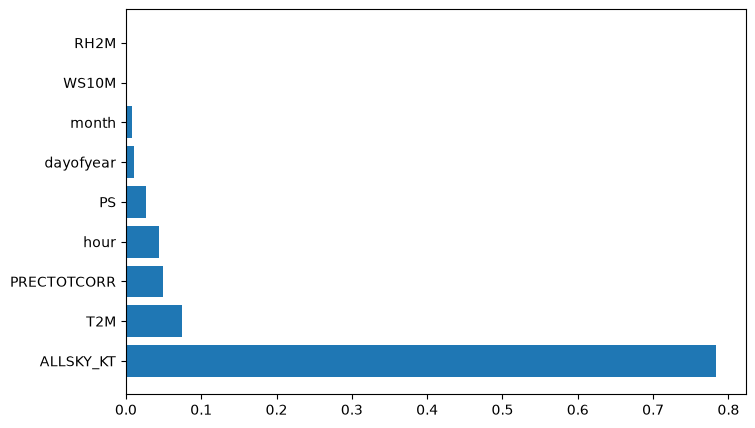

In [13]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.show()

In [14]:
corr = df.corr(numeric_only=True)

target_corr = (
    corr["ALLSKY_SFC_SW_DWN"].sort_values(ascending=False)
)
print(target_corr)

ALLSKY_SFC_SW_DWN    1.000000
ALLSKY_KT            0.878228
T2M                  0.454391
WS10M                0.102754
HR                   0.001677
hour                 0.001677
DY                  -0.008313
YEAR                -0.020827
PS                  -0.036049
PRECTOTCORR         -0.043065
month               -0.084107
MO                  -0.084107
dayofyear           -0.084962
RH2M                -0.391687
SZA                 -0.923705
Name: ALLSKY_SFC_SW_DWN, dtype: float64


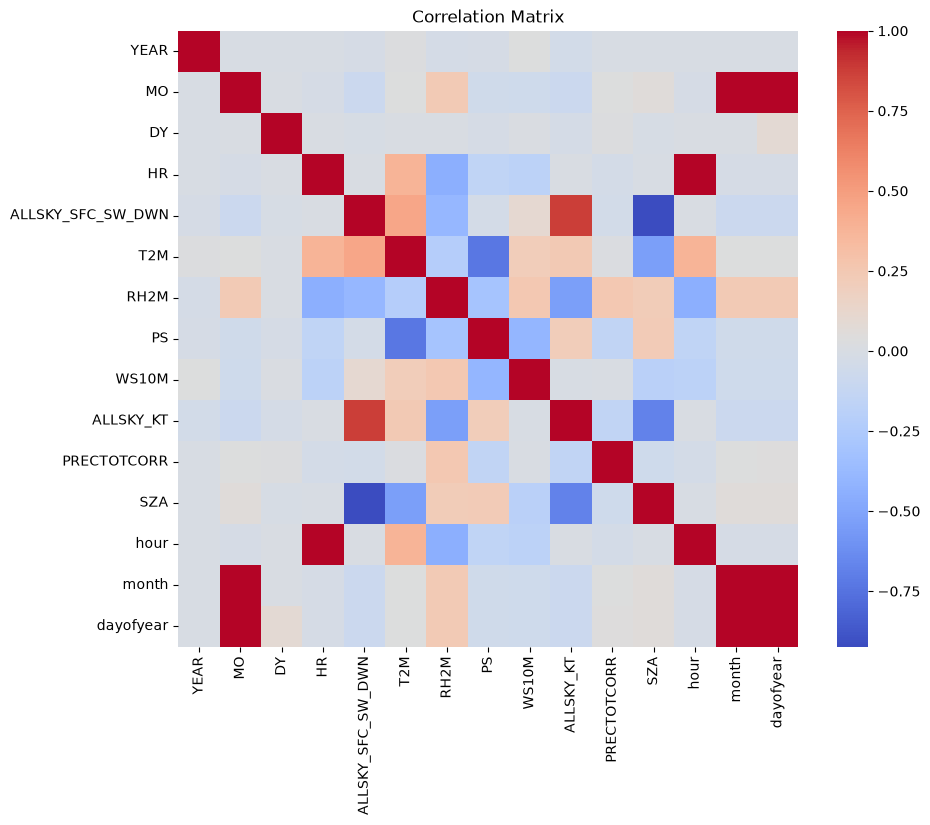

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr, 
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
df["target_1h"] = df["ALLSKY_SFC_SW_DWN"].shift(-1)
df["target_6h"] = df["ALLSKY_SFC_SW_DWN"].shift(-6)
df["target_12h"] = df["ALLSKY_SFC_SW_DWN"].shift(-12)
df["target_24h"] = df["ALLSKY_SFC_SW_DWN"].shift(-24)

df.dropna(inplace=True)

In [17]:
y = df["target_1h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [18]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
pred = xgb.predict(X_test)

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 19.875674939437967
RMSE : 32.0930155766684
R2 : 0.987495131582205


In [22]:
y = df["target_6h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

In [23]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 44.87855479217347
RMSE : 68.4361329953705
R2 : 0.9431919160458407


In [26]:
y = df["target_6h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 44.87855479217347
RMSE : 68.4361329953705
R2 : 0.9431919160458407


In [27]:
y = df["target_12h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 50.933216563492046
RMSE : 80.53743672992564
R2 : 0.9212717391613586


In [28]:
y = df["target_24h"]
X = df[
    ["ALLSKY_KT",
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "PRECTOTCORR",
    "hour",
    "month",
    "dayofyear"]
]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimator = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(
    mean_squared_error(y_test,pred)
)

r2 = r2_score(y_test,pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAE : 58.9035159123517
RMSE : 89.47087164669574
R2 : 0.9028227227245345


In [29]:
results = pd.DataFrame({
    "Horizon":["1h", "6h", "12h", "24h"],
    "MAE":[14.549200473794729,44.87855479217347,50.933216563492046,58.9035159123517],
    "RMSE":[20.353478640472076,68.4361329953705,80.53743672992564,89.47087164669574],
    "R2":[0.9949658559917516,0.9431919160458407,0.9212717391613586,0.9028227227245345]
})

print(results)

  Horizon        MAE       RMSE        R2
0      1h  14.549200  20.353479  0.994966
1      6h  44.878555  68.436133  0.943192
2     12h  50.933217  80.537437  0.921272
3     24h  58.903516  89.470872  0.902823


In [30]:
xgb.fit(X_train,y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [16:11:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
train_residuals = y_train.values - xgb_train_pred
test_residuals = y_test.values - xgb_test_pred

print(train_residuals[:10])

[ 10.09067383  17.14231689  12.70231445  42.18287354  17.71967773
  13.35040283 -25.21514282  -6.71398926  13.28125442   1.96968384]


In [32]:
from sklearn.preprocessing import MinMaxScaler

res_scaler = MinMaxScaler()

train_residuals_scaled = res_scaler.fit_transform(
    train_residuals.reshape(-1,1)
)

test_residuals_scaled = res_scaler.transform(
    test_residuals.reshape(-1,1)
)

In [33]:
lookback = 24

import numpy as np

def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(len(data)-lookback):

        X.append(data[i:i+lookback])

        y.append(data[i+lookback])

    return np.array(X), np.array(y)

X_res_train, y_res_train = create_sequences(
    train_residuals_scaled,
    lookback
)

X_res_test, y_res_test = create_sequences(
    test_residuals_scaled,
    lookback
)

In [34]:
print(X_res_train.shape)
print(y_res_train.shape)

(25439, 24, 1)
(25439, 1)


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [36]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(lookback,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/Users/ak/Desktop/projects/DL_wind_solar_forecast/tf_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_res_train,
    y_res_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0093 - val_loss: 0.0038
Epoch 2/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 3/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 4/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 5/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0026
Epoch 6/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 7/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 8/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 9/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 10/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 11/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 12/40
716/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

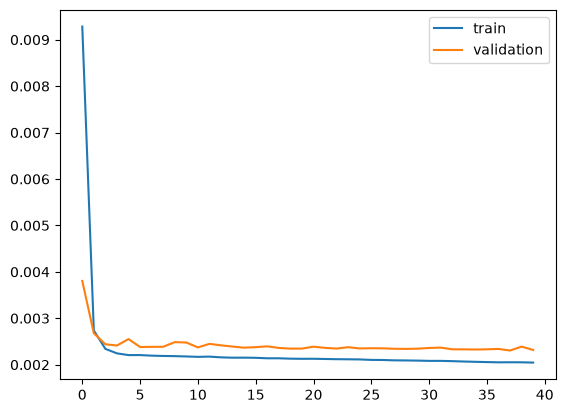

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()

In [39]:
residual_pred_scaled = model.predict(
    X_res_test
)

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step


In [40]:
residual_pred = res_scaler.inverse_transform(
    residual_pred_scaled
)

In [41]:
lookback = 24
xgb_test_aligned = xgb_test_pred[lookback:]

y_test_aligned = y_test.values[lookback:]

hybrid_pred = (
    xgb_test_aligned
    +
    residual_pred.flatten()
)

Hybrid MAE : 33.926186201660386
Hybrid RMSE : 47.75698015650622
Hybrid R2 : 0.9723233492397209
    YEAR  MO  DY  HR  ALLSKY_SFC_SW_DWN    T2M   RH2M     PS  WS10M  \
7   2019   1   1   7              34.40   9.85  24.34  99.64   1.96   
8   2019   1   1   8             201.65  12.79  20.38  99.74   1.74   
9   2019   1   1   9             387.85  15.25  17.19  99.76   2.06   
10  2019   1   1  10             540.03  18.34  14.12  99.70   1.85   
11  2019   1   1  11             635.28  22.06  10.48  99.57   1.16   

    ALLSKY_KT  PRECTOTCORR    SZA            datetime  hour  month  dayofyear  \
7        0.34          0.0  85.92 2019-01-01 07:00:00     7      1          1   
8        0.55          0.0  74.76 2019-01-01 08:00:00     8      1          1   
9        0.64          0.0  64.67 2019-01-01 09:00:00     9      1          1   
10       0.70          0.0  56.51 2019-01-01 10:00:00    10      1          1   
11       0.72          0.0  51.22 2019-01-01 11:00:00    11      1       

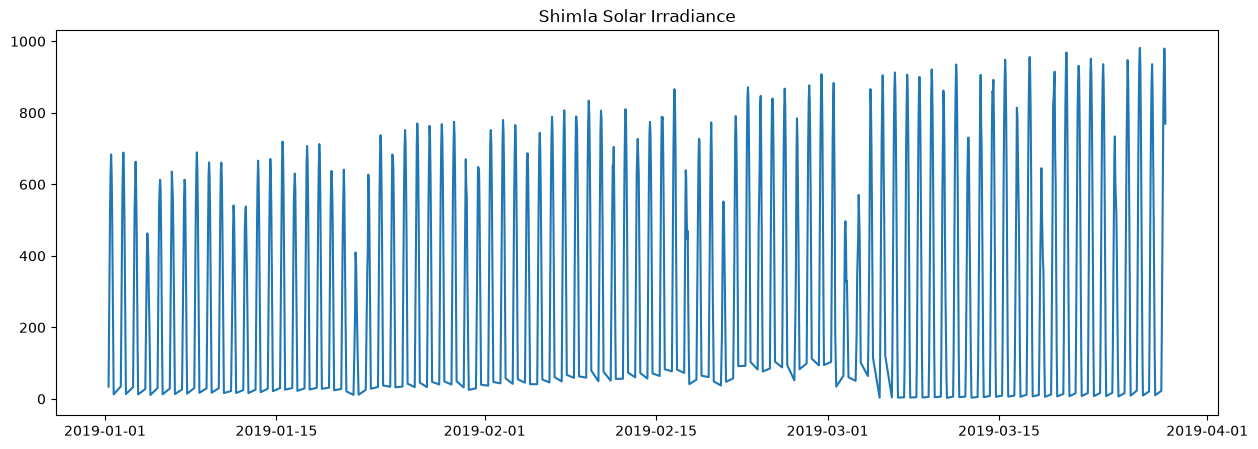

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test_aligned,
    hybrid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_aligned,
        hybrid_pred
    )
)

r2 = r2_score(
    y_test_aligned,
    hybrid_pred
)

print("Hybrid MAE :", mae)
print("Hybrid RMSE :", rmse)
print("Hybrid R2 :", r2)


print(df.head())
print(df.shape)


plt.figure(figsize=(15,5))

plt.plot(
    df["datetime"][:1000],
    df["ALLSKY_SFC_SW_DWN"][:1000]
)

plt.title("Shimla Solar Irradiance")
plt.show()